In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Paths
MERCARI_PATH  = '/Users/nejam_abderrahmane/Downloads/Split_Files/Mercari.xlsx'
BENCHMARK_DIR = '/Users/nejam_abderrahmane/Downloads/Gemma4_Benchmarks'

# ── Ground-truth column names in Mercari.xlsx
# Update these if your spreadsheet uses different names.
TITLE_COL   = 'item_name'
TRUE_L1_COL = 'category_1'
TRUE_L2_COL = 'category_2'
TRUE_L3_COL = 'category_3'

# ── Models to evaluate — label : prediction filename
MODELS = {
    'E2B'    : 'Gemma4_E2B_Predictions.xlsx',
    'E4B'    : 'Gemma4_E4B_Predictions.xlsx',
    '12B'    : 'Gemma4_12B_Predictions.xlsx',
    '26B MoE': 'Gemma4_26B_MoE_Predictions.xlsx',
    '31B'    : 'Gemma4_31B_Predictions.xlsx',
}

N_ITEMS = 100   # benchmark was run on top-100 rows

print('✅ Config ready.')

✅ Config ready.


In [2]:
print('Loading ground truth from Mercari.xlsx...')

mercari_df = pd.read_excel(MERCARI_PATH).head(N_ITEMS).copy().reset_index(drop=True)

# Validate expected columns exist
missing = [c for c in [TITLE_COL, TRUE_L1_COL, TRUE_L2_COL, TRUE_L3_COL]
           if c not in mercari_df.columns]
if missing:
    print(f'⚠️  Column(s) not found in Mercari.xlsx: {missing}')
    print(f'   Available columns: {list(mercari_df.columns)}')
    print('   Update the TRUE_L*_COL variables in Cell 1 to match your spreadsheet.')
else:
    print(f'✅ Ground truth loaded — {len(mercari_df)} items.')
    print(f'   Sample:\n{mercari_df[[TRUE_L1_COL, TRUE_L2_COL, TRUE_L3_COL]].head(3).to_string()}')

Loading ground truth from Mercari.xlsx...
✅ Ground truth loaded — 100 items.
   Sample:
     category_1  category_2 category_3
0  ゲーム・おもちゃ・グッズ  トレーディングカード        その他
1  ゲーム・おもちゃ・グッズ   キャラクターグッズ   アクリルスタンド
2  ゲーム・おもちゃ・グッズ   キャラクターグッズ        その他


In [3]:
def compute_accuracy(ground_truth: pd.DataFrame, predictions: pd.DataFrame) -> dict:
    """Merge on item_name and compute exact-match accuracy at each level."""
    merged = ground_truth[[TITLE_COL, TRUE_L1_COL, TRUE_L2_COL, TRUE_L3_COL]].merge(
        predictions[['item_name', 'category_1_pred', 'category_2_pred', 'category_3_pred']],
        left_on=TITLE_COL, right_on='item_name', how='inner'
    )

    n = len(merged)
    if n == 0:
        print('  ⚠️  No matching rows after merge — check that item_name values align.')
        return {'L1': 0.0, 'L2': 0.0, 'L3': 0.0, 'n': 0}

    def pct(col_true, col_pred):
        return (merged[col_true].astype(str).str.strip().str.lower() ==
                merged[col_pred].astype(str).str.strip().str.lower()).sum() / n * 100

    return {
        'L1': pct(TRUE_L1_COL, 'category_1_pred'),
        'L2': pct(TRUE_L2_COL, 'category_2_pred'),
        'L3': pct(TRUE_L3_COL, 'category_3_pred'),
        'n' : n
    }


results = {}
print('Computing accuracy...\n')

for label, filename in MODELS.items():
    filepath = os.path.join(BENCHMARK_DIR, filename)
    if not os.path.exists(filepath):
        print(f'  ⚠️  {label}: file not found ({filename}) — skipping.')
        continue
    pred_df  = pd.read_excel(filepath)
    accuracy = compute_accuracy(mercari_df, pred_df)
    results[label] = accuracy
    print(f'  {label:8s}  L1: {accuracy["L1"]:5.1f}%  '
          f'L2: {accuracy["L2"]:5.1f}%  '
          f'L3: {accuracy["L3"]:5.1f}%  '
          f'(n={accuracy["n"]})')

print(f'\n✅ Evaluated {len(results)} model(s).')

Computing accuracy...

  E2B       L1:  33.7%  L2:  22.1%  L3:  21.2%  (n=104)
  E4B       L1:  36.5%  L2:  27.9%  L3:  28.8%  (n=104)
  12B       L1:  51.0%  L2:  44.2%  L3:  45.2%  (n=104)
  26B MoE   L1:  71.2%  L2:  59.6%  L3:  53.8%  (n=104)
  31B       L1:  76.0%  L2:  63.5%  L3:  55.8%  (n=104)

✅ Evaluated 5 model(s).


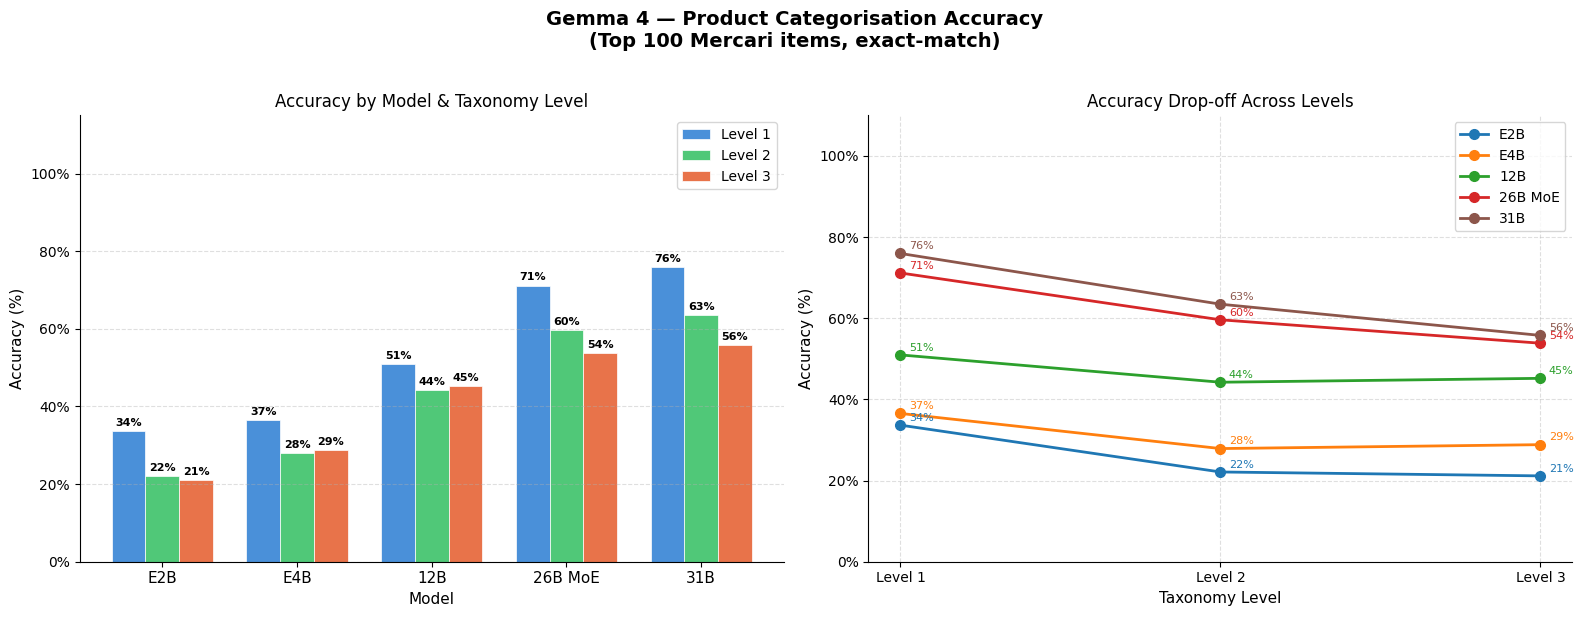


📊 Chart saved → /Users/nejam_abderrahmane/Downloads/Gemma4_Benchmarks/Gemma4_Accuracy_Benchmark.png


In [4]:
if not results:
    print('No results to plot — run Cell 3 first.')
else:
    models  = list(results.keys())
    l1_vals = [results[m]['L1'] for m in models]
    l2_vals = [results[m]['L2'] for m in models]
    l3_vals = [results[m]['L3'] for m in models]

    x      = np.arange(len(models))
    width  = 0.25
    colors = ['#4A90D9', '#50C878', '#E8734A']   # blue / green / orange

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Gemma 4 — Product Categorisation Accuracy\n'
                 f'(Top {N_ITEMS} Mercari items, exact-match)',
                 fontsize=14, fontweight='bold', y=1.02)

    # ── Left: grouped bar chart
    ax = axes[0]
    bars1 = ax.bar(x - width, l1_vals, width, label='Level 1', color=colors[0], edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x,         l2_vals, width, label='Level 2', color=colors[1], edgecolor='white', linewidth=0.5)
    bars3 = ax.bar(x + width, l3_vals, width, label='Level 3', color=colors[2], edgecolor='white', linewidth=0.5)

    def label_bars(bars):
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                        f'{h:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    label_bars(bars1); label_bars(bars2); label_bars(bars3)

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 115)
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title('Accuracy by Model & Taxonomy Level', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    # ── Right: line chart — accuracy drop-off across levels
    ax2 = axes[1]
    level_labels = ['Level 1', 'Level 2', 'Level 3']
    line_colors  = plt.cm.tab10(np.linspace(0, 0.5, len(models)))

    for i, model in enumerate(models):
        vals = [results[model]['L1'], results[model]['L2'], results[model]['L3']]
        ax2.plot(level_labels, vals, marker='o', linewidth=2,
                 markersize=7, label=model, color=line_colors[i])
        for j, v in enumerate(vals):
            ax2.annotate(f'{v:.0f}%', (j, v),
                         textcoords='offset points', xytext=(6, 3),
                         fontsize=8, color=line_colors[i])

    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_ylim(0, 110)
    ax2.set_xlabel('Taxonomy Level', fontsize=11)
    ax2.set_ylabel('Accuracy (%)', fontsize=11)
    ax2.set_title('Accuracy Drop-off Across Levels', fontsize=12)
    ax2.legend(fontsize=10, loc='upper right')
    ax2.grid(linestyle='--', alpha=0.4)
    ax2.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(BENCHMARK_DIR, 'Gemma4_Accuracy_Benchmark.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n📊 Chart saved → {BENCHMARK_DIR}/Gemma4_Accuracy_Benchmark.png')

In [5]:
if results:
    summary = pd.DataFrame({
        'Model'  : list(results.keys()),
        'L1 Acc' : [f"{results[m]['L1']:.1f}%" for m in results],
        'L2 Acc' : [f"{results[m]['L2']:.1f}%" for m in results],
        'L3 Acc' : [f"{results[m]['L3']:.1f}%" for m in results],
        'Avg Acc': [f"{(results[m]['L1'] + results[m]['L2'] + results[m]['L3']) / 3:.1f}%"
                    for m in results],
        'n Items': [results[m]['n'] for m in results],
    })

    best_l1  = max(results, key=lambda m: results[m]['L1'])
    best_l2  = max(results, key=lambda m: results[m]['L2'])
    best_l3  = max(results, key=lambda m: results[m]['L3'])
    best_avg = max(results, key=lambda m: (results[m]['L1'] + results[m]['L2'] + results[m]['L3']))

    print('=' * 60)
    print('GEMMA 4 ACCURACY BENCHMARK SUMMARY')
    print('=' * 60)
    print(summary.to_string(index=False))
    print('=' * 60)
    print(f'🏆 Best L1 : {best_l1}  ({results[best_l1]["L1"]:.1f}%)')
    print(f'🏆 Best L2 : {best_l2}  ({results[best_l2]["L2"]:.1f}%)')
    print(f'🏆 Best L3 : {best_l3}  ({results[best_l3]["L3"]:.1f}%)')
    print(f'🏆 Best Avg: {best_avg}')
    print('=' * 60)

    summary.to_csv(os.path.join(BENCHMARK_DIR, 'Gemma4_Accuracy_Summary.csv'), index=False)
    print(f'\n📄 Summary saved → {BENCHMARK_DIR}/Gemma4_Accuracy_Summary.csv')

GEMMA 4 ACCURACY BENCHMARK SUMMARY
  Model L1 Acc L2 Acc L3 Acc Avg Acc  n Items
    E2B  33.7%  22.1%  21.2%   25.6%      104
    E4B  36.5%  27.9%  28.8%   31.1%      104
    12B  51.0%  44.2%  45.2%   46.8%      104
26B MoE  71.2%  59.6%  53.8%   61.5%      104
    31B  76.0%  63.5%  55.8%   65.1%      104
🏆 Best L1 : 31B  (76.0%)
🏆 Best L2 : 31B  (63.5%)
🏆 Best L3 : 31B  (55.8%)
🏆 Best Avg: 31B

📄 Summary saved → /Users/nejam_abderrahmane/Downloads/Gemma4_Benchmarks/Gemma4_Accuracy_Summary.csv
